# **Perfil de Densidad**

In [6]:
# Activar autoreload para detectar cambios en funciones.py en tiempo real
%load_ext autoreload
%autoreload 2

# Mostrar los gráficos de Matplotlib directamente debajo de la celda
%matplotlib inline

import os
import glob
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import matplotlib.cm as cm

# Importar tu función adaptada para HOOMD-blue (GSD)
from funciones import calcular_perfil_densidad_gsd 

print("✅ Entorno inicializado y librerías cargadas.")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
✅ Entorno inicializado y librerías cargadas.


📊 Generando perfil para T=0.60 desde: trajectory_T0.60.gsd...
Dimensiones de la caja: Lx=100.0000, Ly=50.0000, Lz=50.0000
Procesando 21 frames de 31 totales...
Frame procesado: 30/31
✅ Cálculo de perfil completado.
📊 Generando perfil para T=0.70 desde: trajectory_T0.70.gsd...
Dimensiones de la caja: Lx=100.0000, Ly=50.0000, Lz=50.0000
Procesando 21 frames de 31 totales...
Frame procesado: 30/31
✅ Cálculo de perfil completado.
📊 Generando perfil para T=0.80 desde: trajectory_T0.80.gsd...
Dimensiones de la caja: Lx=100.0000, Ly=50.0000, Lz=50.0000
Procesando 21 frames de 31 totales...
Frame procesado: 30/31
✅ Cálculo de perfil completado.
📊 Generando perfil para T=0.90 desde: trajectory_T0.90.gsd...
Dimensiones de la caja: Lx=100.0000, Ly=50.0000, Lz=50.0000
Procesando 21 frames de 31 totales...
Frame procesado: 30/31
✅ Cálculo de perfil completado.
📊 Generando perfil para T=1.00 desde: trajectory_T1.00.gsd...
Dimensiones de la caja: Lx=100.0000, Ly=50.0000, Lz=50.0000
Procesando 21 fram

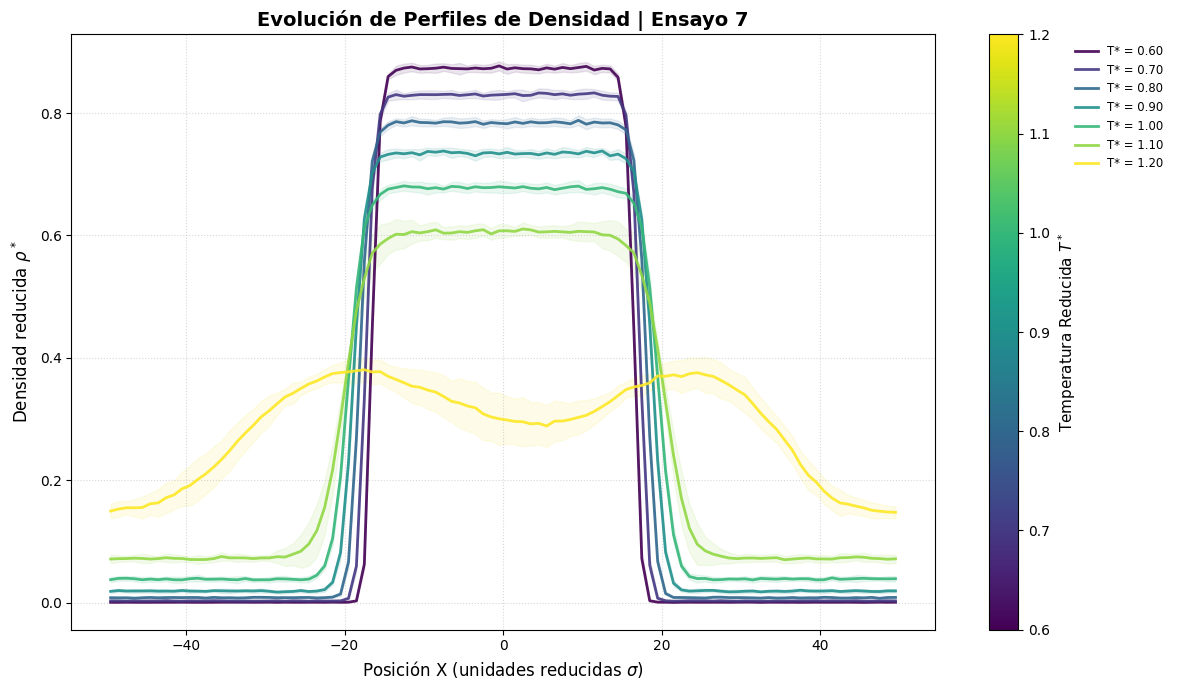

In [7]:
"""
Visualización de la evolución de perfiles de densidad (Gradiente de T).
Adaptado para resultados de HOOMD-blue en Jupyter Notebook.

Fabio Noriega Hernández
Mayo 2026
"""

# -- CONFIGURACIÓN --
num_prueba = 7
num_bines = 100
start_frame = 10  # Frame inicial para el promedio (ajustar según tu simulación)

temperaturas_originales = [0.60, 0.70, 0.80, 0.90, 1.00, 1.10, 1.20]
# Filtramos si alguna temperatura dio error o no se desea graficar
temperaturas = [T for T in temperaturas_originales if T != 0.95]

# Corrección en la celda de tu IPYNB:
configuracion = 'N_64_45_25'

ruta_comun = f'/run/media/fabio-noriega/Almacen_Fabio/Simulaciones/Resultados/HOOMD/P{num_prueba}_HOOMD_Mie'
ruta_graficos = os.path.join(ruta_comun, f'Graficos_Analisis/{configuracion}')

# Crear la carpeta de salida si no existe
os.makedirs(ruta_graficos, exist_ok=True)

# -- CONFIGURACIÓN DEL GRÁFICO --
fig, ax = plt.subplots(figsize=(12, 7))

# Manejo dinámico del mapa de colores por si solo hay 1 temperatura
if len(temperaturas) > 1:
    norm = plt.Normalize(min(temperaturas), max(temperaturas))
else:
    norm = plt.Normalize(temperaturas[0] - 0.1, temperaturas[0] + 0.1)

cmap = cm.viridis

# -- PROCESAMIENTO DE ARCHIVOS GSD --
for T in temperaturas:
    nombre_carpeta = configuracion
    ruta_busqueda = os.path.join(ruta_comun, nombre_carpeta, f"trajectory_T{T:.2f}.gsd")
    archivos = glob.glob(ruta_busqueda)
    
    if not archivos: 
        print(f"⚠️ Saltando T={T:.2f}: Archivo GSD no encontrado en {ruta_busqueda}")
        continue
    
    archivo_actual = archivos[0]
    print(f'📊 Generando perfil para T={T:.2f} desde: {os.path.basename(archivo_actual)}...')

    try:
        # Extracción de datos desde el archivo de trayectoria GSD de HOOMD
        x, rho_prom, rho_std = calcular_perfil_densidad_gsd(
            gsd_file=archivo_actual, 
            start_frame=start_frame, 
            num_bines=num_bines
        )

        color_T = cmap(norm(T))
        
        # Graficamos el perfil medio de densidad
        ax.plot(x, rho_prom, label=f'T* = {T:.2f}', color=color_T, linewidth=2, alpha=0.9)
        
        # Área de desviación estándar (sombreado tenue para fluctuaciones de densidad)
        ax.fill_between(x, rho_prom - rho_std, rho_prom + rho_std, color=color_T, alpha=0.1)

    except Exception as e:
        print(f"❌ Error al procesar T={T}: {e}")

# --- ESTÉTICA DEL GRÁFICO ---
ax.set_title(f'Evolución de Perfiles de Densidad | Ensayo {num_prueba}', fontsize=14, fontweight='bold')
ax.set_xlabel('Posición X (unidades reducidas $\sigma$)', fontsize=12)
ax.set_ylabel('Densidad reducida $\\rho^*$', fontsize=12)

# Barra de colores lateral (Colorbar)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax)
cbar.set_label('Temperatura Reducida $T^*$', fontsize=11)

ax.grid(True, linestyle=':', alpha=0.5)
ax.legend(bbox_to_anchor=(1.15, 1), loc='upper left', fontsize='small', frameon=False)

plt.tight_layout()

# Guardar y desplegar en el notebook
ruta_salida = os.path.join(ruta_graficos, f"Evolucion_Perfiles_P{num_prueba}.png")
plt.savefig(ruta_salida, dpi=300, bbox_inches='tight')
print(f"\n✅ Gráfico guardado exitosamente en:\n 📂 {ruta_salida}")

plt.show()


In [8]:
print(f'La densidad máxima es: {rho_prom.max():.2f} (Debería ser: 0.4367). Con una desviación estándar de: {rho_std.mean():.4f}')
print(f'La densidad mínima es: {rho_prom.min():.2f} (Debería ser: 0.2047). Con una desviación estándar de: {rho_std.mean():.4f}')

La densidad máxima es: 0.38 (Debería ser: 0.4367). Con una desviación estándar de: 0.0240
La densidad mínima es: 0.15 (Debería ser: 0.2047). Con una desviación estándar de: 0.0240
